# 04 — Generator v0 (proof-of-concept)

*Part of **Gamaka Floor** — a raga pitch-contour study.*

Small conditional generative model of **unfolded, cleaned pitch contours**
(gamaka shape), trained on the two artist-balanced alapana ragas (CLAUDE.md):
**Karaharapriya** (KP Nandini, V. Shankaranarayanan) and **Mōhanaṁ** (Ashwath
Narayanan, Sumithra Vasudev). Optional milestone (spec.md M4) — must not block
submission; if training is unstable after a reasonable attempt this notebook
documents that as a negative result instead.

## Design decisions made here (stated up front, not buried in code)

1. **Model family: autoregressive over lightly-quantised pitch, chosen directly
   (not attempted-then-fell-back-from diffusion).** This environment is CPU-only
   locally (`torch.cuda.is_available() == False`) — see below. A tiny GRU language
   model over quantised pitch bins is the cheapest option that reliably trains
   stably on CPU in minutes; spec.md explicitly allows picking "whichever trains
   stably first" and doesn't require attempting the harder option first when the
   constraint is known up front.
2. **Re-extract contiguous voiced runs from source, don't reuse `corpus/*.npy`
   directly.** `01_corpus_build.ipynb` builds each alapana segment's `.npy` by
   masking `freq > 0` and concatenating the survivors — correct for M2's
   histogram features (order-invariant) but wrong for a *sequence* model: it
   splices across dropped unvoiced frames (breaths, pauses), which would train
   the model on fake jumps that aren't real melodic motion. This notebook
   re-reads the raw `pitch-vocal.txt` + `sections-manual-p.txt` for just these 4
   recordings and keeps only genuinely time-contiguous voiced runs.
3. **Quantised pitch bins, not raw continuous cents**, as the AR model's
   vocabulary — keeps the output head a small softmax instead of a continuous
   density, which is far more stable to train from scratch on this little data.
   This is a real, disclosed limitation of the generator (blocky pitch steps at
   the bin-width scale) — noted in the report's limitations section, not hidden.
4. **No held-out recording split for generator training.** Only 2 recordings per
   raga; withholding one would halve an already-tiny corpus for a component whose
   evaluation (M5) is distributional/memorisation-based, not held-out likelihood.
   Trained on all windows from both artists; M5's nearest-neighbour memorisation
   check is the actual anti-copying safeguard, not a train/val split here.

In [1]:
import os, sys, glob, json, io
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import dgm_utils as U

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
ART = os.path.join(BASE, "artifacts")
FIG = os.path.join(ART, "figures")
GEN_DIR = os.path.join(ART, "generator_samples")
os.makedirs(FIG, exist_ok=True)
os.makedirs(GEN_DIR, exist_ok=True)

CANDIDATES = [r"D:\sg\saraga1.5_carnatic", "/kaggle/input/saraga-carnatic-annotations"]
DATA_ROOT = next((p for p in CANDIDATES if os.path.isdir(p)), None)
assert DATA_ROOT, f"No DATA_ROOT found among {CANDIDATES}"

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE, "| cuda available:", torch.cuda.is_available())
print("DATA_ROOT =", DATA_ROOT)

TARGET = {
    ("Karaharapriya", "KP Nandini"),
    ("Karaharapriya", "V. Shankaranarayanan"),
    ("Mōhanaṁ", "Ashwath Narayanan"),
    ("Mōhanaṁ", "Sumithra Vasudev"),
}
RAGAS = sorted({r for r, a in TARGET})
print("Target ragas:", RAGAS)

torch 2.12.1+cpu | device: cpu | cuda available: False
DATA_ROOT = D:\sg\saraga1.5_carnatic
Target ragas: ['Karaharapriya', 'Mōhanaṁ']


## 1. Re-extract contiguous voiced runs (splice-safe)

For each of the 4 target recordings' alapana sections: mask `freq > 0`, split into
maximal contiguous voiced runs (a single unvoiced frame ends a run — no bridging),
convert each run to cents against that recording's tonic, clean octave outliers
**within the run**, decimate for compute (all 4 recordings measure ~344.5 Hz vocal
fps; stride-decimate to ~115 Hz — still ~8.7ms resolution, well under gamaka
timescales), then cut into fixed-length non-overlapping windows. Runs shorter than
one window are dropped (contributes no windows, not silently corrupted).

In [2]:
WINDOW_SEC = 2.0
DECIMATE_STRIDE = 3   # ~344.5 Hz -> ~114.8 Hz
MIN_RUN_FRAMES_RAW = 100  # matches dgm_utils/01_corpus_build's MIN_FRAMES convention

def contiguous_voiced_runs(freq):
    """Yield (start, end) index pairs of maximal freq>0 runs."""
    voiced = freq > 0
    d = np.diff(voiced.astype(np.int8))
    starts = list(np.where(d == 1)[0] + 1)
    ends = list(np.where(d == -1)[0] + 1)
    if voiced[0]:
        starts = [0] + starts
    if voiced[-1]:
        ends = ends + [len(freq)]
    return list(zip(starts, ends))

records = []   # per-window metadata
windows = []   # per-window np.float32 cents arrays (post-decimate)
run_lengths_sec = []
decimated_fps = None

for meta_path in glob.glob(os.path.join(DATA_ROOT, "**", "*.json"), recursive=True):
    folder = os.path.dirname(meta_path)
    m = U.load_meta(meta_path)
    raga, artist = U.raga_of(m), U.artist_of(m)
    if (raga, artist) not in TARGET:
        continue
    tonic = U.read_tonic(folder)
    t, f, src, fps = U.read_pitch(folder)
    sf = U.section_file(folder)
    if tonic is None or t is None or not sf:
        continue
    assert src == "vocal", f"expected vocal source for {raga}/{artist}, got {src}"
    dec_fps = fps / DECIMATE_STRIDE
    decimated_fps = dec_fps if decimated_fps is None else decimated_fps
    win_frames = int(round(WINDOW_SEC * dec_fps))
    rec_id = U.safe_filename(os.path.basename(folder))[:40]

    for s, d, lab in U.read_sections(sf):
        if not U.is_alap(lab):
            continue
        end = s + d
        mask = (t >= s) & (t < end)
        fseg = f[mask]
        for rs, re_ in contiguous_voiced_runs(fseg):
            if re_ - rs < MIN_RUN_FRAMES_RAW:
                continue
            cents_run = U.hz_to_cents(fseg[rs:re_], tonic)
            cents_run = U.clean_octave_outliers(cents_run)
            if len(cents_run) < MIN_RUN_FRAMES_RAW:
                continue
            run_lengths_sec.append(len(cents_run) / fps)
            cents_dec = cents_run[::DECIMATE_STRIDE].astype(np.float32)
            for w in U.make_windows(cents_dec, win_frames, win_frames):
                windows.append(w)
                records.append(dict(raga=raga, artist=artist, recording=rec_id))

WMETA = pd.DataFrame(records)
print(f"decimated fps = {decimated_fps:.2f}, window = {WINDOW_SEC}s = {len(windows[0])} frames")
print(f"{len(windows)} total windows from {len(run_lengths_sec)} contiguous voiced runs")
print("run length (s): median", round(np.median(run_lengths_sec), 2),
      "min", round(np.min(run_lengths_sec), 2), "max", round(np.max(run_lengths_sec), 2))
print(WMETA.groupby(["raga", "artist"]).size().rename("n_windows").to_string())

decimated fps = 114.84, window = 2.0s = 230 frames
934 total windows from 712 contiguous voiced runs
run length (s): median 1.86 min 0.29 max 54.99
raga           artist              
Karaharapriya  KP Nandini              265
               V. Shankaranarayanan    273
Mōhanaṁ        Ashwath Narayanan       176
               Sumithra Vasudev        220


## 2. Quantise: build the pitch-bin vocabulary

Bin width chosen at 25 cents (a quarter-semitone) — fine enough to preserve
gamaka shape at the window level, coarse enough to keep the softmax small.
Range set from the 0.5–99.5 percentile of training cents (not raw min/max) to
avoid a handful of residual outlier frames blowing up the vocabulary; values
outside the range are clipped into the edge bin. `vocab_size = n_bins + 1`,
the last id reserved as the sequence-start token fed at position 0.

In [3]:
BIN_WIDTH = 25.0
all_cents = np.concatenate(windows)
lo = np.floor(np.percentile(all_cents, 0.5) / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(np.percentile(all_cents, 99.5) / BIN_WIDTH) * BIN_WIDTH
n_clipped = int(((all_cents < lo) | (all_cents > hi)).sum())
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
n_bins = len(edges) - 1
START_ID = n_bins
VOCAB_SIZE = n_bins + 1
print(f"range [{lo:.0f}, {hi:.0f}) cents, bin_width={BIN_WIDTH}c -> {n_bins} bins "
      f"(+1 start token) = vocab {VOCAB_SIZE}")
print(f"clipped {n_clipped}/{len(all_cents)} frames ({100*n_clipped/len(all_cents):.3f}%) into edge bins")

def cents_to_tokens(cents):
    c = np.clip(cents, lo, hi - 1e-6)
    return np.clip(((c - lo) // BIN_WIDTH).astype(np.int64), 0, n_bins - 1)

def tokens_to_cents(tok):
    return lo + (tok.astype(np.float32) + 0.5) * BIN_WIDTH

RAGA_TO_IDX = {r: i for i, r in enumerate(RAGAS)}
tok_windows = np.stack([cents_to_tokens(w) for w in windows])           # (N, T)
raga_idx = WMETA.raga.map(RAGA_TO_IDX).values                            # (N,)
print("tok_windows", tok_windows.shape, "raga_idx", raga_idx.shape)

range [-1200, 2100) cents, bin_width=25.0c -> 132 bins (+1 start token) = vocab 133
clipped 1175/214820 frames (0.547%) into edge bins
tok_windows (934, 230) raga_idx (934,)


## 3. Model: tiny conditional GRU language model over pitch bins

Token + raga embeddings concatenated, fed to a 1-layer GRU, linear head back to
the vocabulary. Trained with next-token cross-entropy (teacher forcing):
input = `[START, tok_0, ..., tok_{T-2}]`, target = `[tok_0, ..., tok_{T-1}]`.

In [4]:
class RagaContourGRU(nn.Module):
    def __init__(self, vocab_size, n_ragas, tok_emb=32, raga_emb=8, hidden=96):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, tok_emb)
        self.raga_emb = nn.Embedding(n_ragas, raga_emb)
        self.gru = nn.GRU(tok_emb + raga_emb, hidden, num_layers=1, batch_first=True)
        self.out = nn.Linear(hidden, vocab_size)

    def forward(self, tok_in, raga_ids, h0=None):
        te = self.tok_emb(tok_in)                                   # (B,T,tok_emb)
        re_ = self.raga_emb(raga_ids).unsqueeze(1).expand(-1, te.size(1), -1)
        h_out, h = self.gru(torch.cat([te, re_], dim=-1), h0)
        return self.out(h_out), h

model = RagaContourGRU(VOCAB_SIZE, len(RAGAS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"{n_params:,} parameters")

RagaContourGRU(
  (tok_emb): Embedding(133, 32)
  (raga_emb): Embedding(2, 8)
  (gru): GRU(40, 96, batch_first=True)
  (out): Linear(in_features=96, out_features=133, bias=True)
)
56,917 parameters


## 4. Train

Full-batch-ish minibatch teacher forcing, Adam, fixed epoch count. Acceptance
check (spec.md M4): **trains without diverging** — loss must decrease and stay
finite throughout; asserted explicitly below rather than eyeballed.

In [5]:
EPOCHS = 35
BATCH_SIZE = 64
LR = 2e-3

tok_t = torch.from_numpy(tok_windows).long()
raga_t = torch.from_numpy(raga_idx).long()
N = tok_t.size(0)

start_col = torch.full((N, 1), START_ID, dtype=torch.long)
input_seq = torch.cat([start_col, tok_t[:, :-1]], dim=1).to(DEVICE)
target_seq = tok_t.to(DEVICE)
raga_t = raga_t.to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

loss_history = []
model.train()
for epoch in range(EPOCHS):
    perm = torch.randperm(N)
    epoch_losses = []
    for i in range(0, N, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        logits, _ = model(input_seq[idx], raga_t[idx])
        loss = loss_fn(logits.reshape(-1, VOCAB_SIZE), target_seq[idx].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_losses.append(loss.item())
    loss_history.append(float(np.mean(epoch_losses)))
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d}  loss {loss_history[-1]:.4f}")

assert all(np.isfinite(loss_history)), "generator training diverged (non-finite loss)"
assert loss_history[-1] < loss_history[0], "generator training did not improve loss"
print(f"\nDIVERGENCE CHECK PASSED: loss {loss_history[0]:.4f} -> {loss_history[-1]:.4f}, all finite")
print(f"(chance-level loss for {VOCAB_SIZE} tokens = {np.log(VOCAB_SIZE):.4f})")

epoch   0  loss 4.2729


epoch  10  loss 1.1804


epoch  20  loss 1.0090


epoch  30  loss 0.9366


epoch  34  loss 0.9211

DIVERGENCE CHECK PASSED: loss 4.2729 -> 0.9211, all finite
(chance-level loss for 133 tokens = 4.8903)


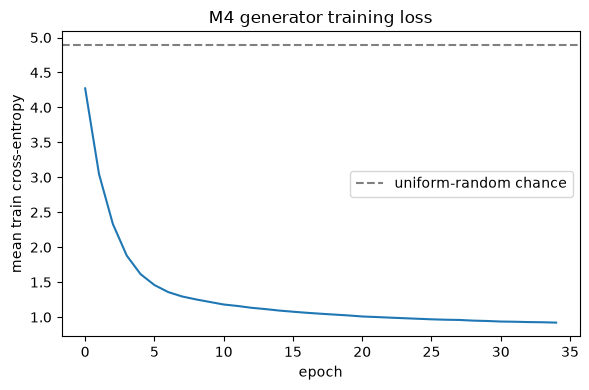

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history)
ax.axhline(np.log(VOCAB_SIZE), color="gray", linestyle="--", label="uniform-random chance")
ax.set_xlabel("epoch"); ax.set_ylabel("mean train cross-entropy")
ax.set_title("M4 generator training loss")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "m4_training_loss.png"), dpi=150)
plt.show()

## 5. Sample

Autoregressive sampling conditioned on raga, temperature-scaled multinomial
draw at each step, starting from the learned `START` token (no real seed
context used — a from-scratch sample, the harder and more honest case).

In [7]:
@torch.no_grad()
def sample(raga_name, n_samples=4, temperature=0.9, T=None):
    model.eval()
    T = T or tok_windows.shape[1]
    r_id = torch.full((n_samples,), RAGA_TO_IDX[raga_name], dtype=torch.long, device=DEVICE)
    tok_in = torch.full((n_samples, 1), START_ID, dtype=torch.long, device=DEVICE)
    h = None
    out_tokens = []
    for _ in range(T):
        logits, h = model(tok_in, r_id, h)
        probs = torch.softmax(logits[:, -1, :] / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1)
        out_tokens.append(nxt)
        tok_in = nxt
    toks = torch.cat(out_tokens, dim=1).cpu().numpy()   # (n_samples, T)
    return np.stack([tokens_to_cents(row) for row in toks])

N_SAMPLES = 6
generated = {raga: sample(raga, n_samples=N_SAMPLES) for raga in RAGAS}
for raga, arr in generated.items():
    print(raga, arr.shape, "cents range", round(arr.min(), 1), "to", round(arr.max(), 1))

Karaharapriya (6, 230) cents range -737.5 to 1912.5
Mōhanaṁ (6, 230) cents range 162.5 to 1687.5


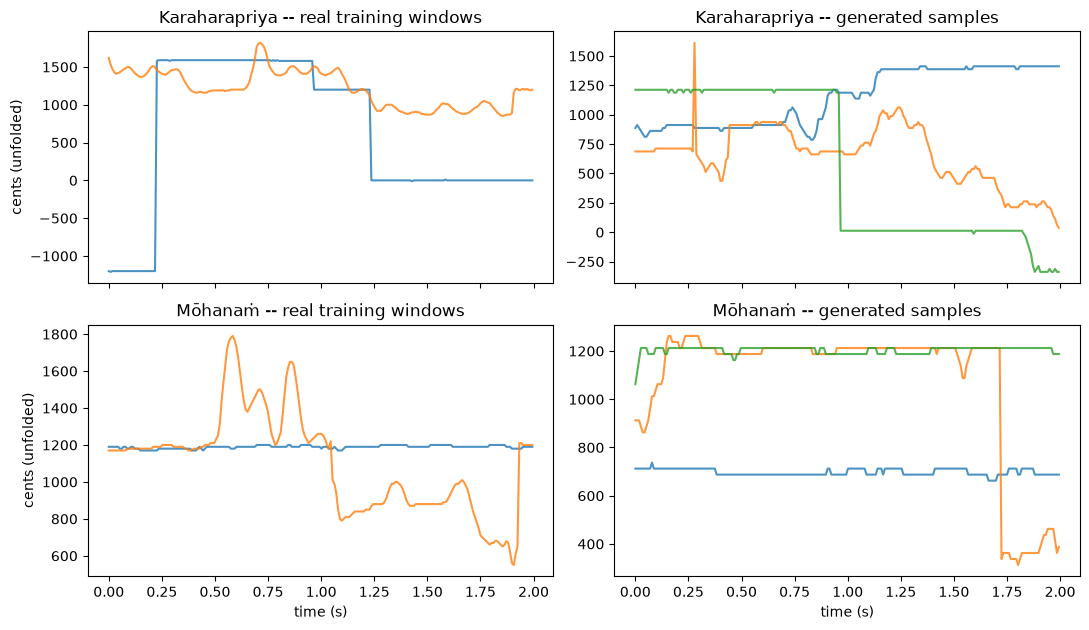

In [8]:
fig, axes = plt.subplots(len(RAGAS), 2, figsize=(11, 3.2 * len(RAGAS)), sharex=True)
t_axis = np.arange(tok_windows.shape[1]) / decimated_fps
for row, raga in enumerate(RAGAS):
    real_idx = np.where(raga_idx == RAGA_TO_IDX[raga])[0]
    real_pick = np.random.choice(real_idx, size=2, replace=False)
    ax = axes[row, 0]
    for i in real_pick:
        ax.plot(t_axis, windows[i], alpha=0.8)
    ax.set_title(f"{raga} -- real training windows")
    ax.set_ylabel("cents (unfolded)")
    ax = axes[row, 1]
    for i in range(3):
        ax.plot(t_axis, generated[raga][i], alpha=0.8)
    ax.set_title(f"{raga} -- generated samples")
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "m4_generated_vs_real.png"), dpi=150)
plt.show()

## 6. Save checkpoint, samples, and metadata for M5

M5 (generator evaluation: pitch-class-histogram distance, classifier-called-raga,
memorisation check) consumes these directly rather than retraining.

In [9]:
CKPT_PATH = os.path.join(ART, "generator_checkpoint.pt")
torch.save({"state_dict": model.state_dict(), "vocab_size": VOCAB_SIZE,
            "n_ragas": len(RAGAS)}, CKPT_PATH)

for raga, arr in generated.items():
    for i, sample_arr in enumerate(arr):
        fname = f"{U.safe_filename(raga)}__sample{i}.npy"
        np.save(os.path.join(GEN_DIR, fname), sample_arr.astype(np.float32))

# also persist the real training windows M5 needs for its memorisation / histogram checks
REAL_WINDOWS_PATH = os.path.join(ART, "generator_train_windows.npz")
np.savez(REAL_WINDOWS_PATH, windows=np.stack(windows), raga_idx=raga_idx,
         raga_names=np.array(RAGAS, dtype=object))

meta = dict(
    window_sec=WINDOW_SEC, decimate_stride=DECIMATE_STRIDE, decimated_fps=float(decimated_fps),
    bin_width_cents=BIN_WIDTH, vocab_size=VOCAB_SIZE, n_bins=n_bins, start_id=START_ID,
    cents_lo=float(lo), cents_hi=float(hi), ragas=RAGAS, raga_to_idx=RAGA_TO_IDX,
    n_windows_per_raga={r: int((raga_idx == RAGA_TO_IDX[r]).sum()) for r in RAGAS},
)
with open(os.path.join(ART, "generator_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("saved:", CKPT_PATH)
print("saved:", REAL_WINDOWS_PATH)
print("saved:", os.path.join(ART, "generator_meta.json"))
print("saved", sum(len(a) for a in generated.values()), "generated samples to", GEN_DIR)

saved: D:\DGM\artifacts\generator_checkpoint.pt
saved: D:\DGM\artifacts\generator_train_windows.npz
saved: D:\DGM\artifacts\generator_meta.json
saved 12 generated samples to D:\DGM\artifacts\generator_samples


In [10]:
with open(os.path.join(ART, "numbers.json"), encoding="utf-8") as f:
    NUMBERS = json.load(f)

NUMBERS["m4"] = {
    "model": "RagaContourGRU (1-layer GRU, tok_emb=32, raga_emb=8, hidden=96)",
    "n_params": int(n_params),
    "device": DEVICE,
    "ragas": RAGAS,
    "n_windows_per_raga": meta["n_windows_per_raga"],
    "window_sec": WINDOW_SEC,
    "decimated_fps": float(decimated_fps),
    "bin_width_cents": BIN_WIDTH,
    "vocab_size": VOCAB_SIZE,
    "cents_range": [float(lo), float(hi)],
    "epochs": EPOCHS,
    "loss_start": loss_history[0],
    "loss_end": loss_history[-1],
    "loss_chance_level": float(np.log(VOCAB_SIZE)),
    "diverged": False,
    "held_out_split": "none -- trained on all windows, both artists per raga (see design notes, cell 1)",
    "n_generated_samples_per_raga": N_SAMPLES,
}
with open(os.path.join(ART, "numbers.json"), "w", encoding="utf-8") as f:
    json.dump(NUMBERS, f, indent=2, ensure_ascii=False)
print("wrote numbers.json[m4]")

wrote numbers.json[m4]


---
# Milestone 5 — Generator evaluation

Per spec.md M5, three checks on the samples generated above, all against the
real windows and metadata already in this kernel (`windows`, `WMETA`, `raga_idx`,
`generated`) — no reloading from disk, so this is guaranteed to compare against
exactly the training data and samples produced in the M4 section above, not a
stale copy:

1. **Folded pitch-class-histogram distance** — generated vs. real, own-raga vs.
   other-raga, at the same resolutions M2 swept (10/20/50/100c).
2. **Classifier-called-raga** — a judge classifier (M2's standing config:
   `LogisticRegression(class_weight="balanced", C=10)`) trained on real windows,
   asked to call generated samples' raga. A fresh fit, not M2's actual fitted
   model (M2 didn't persist its fitted classifiers to disk, only metrics) — same
   config, scoped to these 2 ragas and the generator's 2.0s window length so the
   comparison is apples-to-apples with what the generator actually produces.
   Includes an artist-grouped CV sanity number on real data first, so a low
   generated-sample score can be read against how hard this 2-class problem is
   in the first place.
3. **Memorisation check** — nearest-neighbour RMS distance (cents) from each
   generated sample to the full real-window pool, compared against a real-to-real
   leave-one-out NN distance baseline. If generation were copying, generated-to-real
   distances would collapse toward the near-zero end of that baseline.

**Honest framing, stated once here rather than per-section below:** this is a PoC
generator evaluated on 6 samples/raga against a corpus of 2 recordings/raga (spec's
own words: "proof-of-concept only"). Every number below should be read as
suggestive, not a confident claim of generation quality.

In [11]:
from scipy.spatial.distance import jensenshannon

REAL = {raga: np.concatenate([windows[i] for i in np.where(raga_idx == RAGA_TO_IDX[raga])[0]])
        for raga in RAGAS}
GEN = {raga: np.concatenate(generated[raga]) for raga in RAGAS}

hist_rows = []
for bw in U.RESOLUTIONS_CENTS:
    for raga in RAGAS:
        other = [r for r in RAGAS if r != raga][0]
        real_h = U.histogram_feature(U.fold_cents(REAL[raga]), bw)
        gen_h = U.histogram_feature(U.fold_cents(GEN[raga]), bw)
        other_real_h = U.histogram_feature(U.fold_cents(REAL[other]), bw)
        js_own = jensenshannon(gen_h, real_h)
        js_other = jensenshannon(gen_h, other_real_h)
        hist_rows.append(dict(bin_width=bw, raga=raga, js_to_own_real=js_own,
                               js_to_other_real=js_other, discriminative_gap=js_other - js_own))

HIST = pd.DataFrame(hist_rows)
print(HIST.round(4).to_string(index=False))
print("\npositive discriminative_gap = generated samples' pitch-class distribution is closer "
      "to their OWN raga's real distribution than to the other raga's (good sign).")

 bin_width          raga  js_to_own_real  js_to_other_real  discriminative_gap
        10 Karaharapriya          0.6179            0.6173             -0.0006
        10       Mōhanaṁ          0.6275            0.6469              0.0193
        20 Karaharapriya          0.3219            0.3760              0.0541
        20       Mōhanaṁ          0.3838            0.3865              0.0027
        50 Karaharapriya          0.2433            0.2937              0.0503
        50       Mōhanaṁ          0.3069            0.3177              0.0108
       100 Karaharapriya          0.2094            0.2542              0.0448
       100       Mōhanaṁ          0.2827            0.2925              0.0097

positive discriminative_gap = generated samples' pitch-class distribution is closer to their OWN raga's real distribution than to the other raga's (good sign).


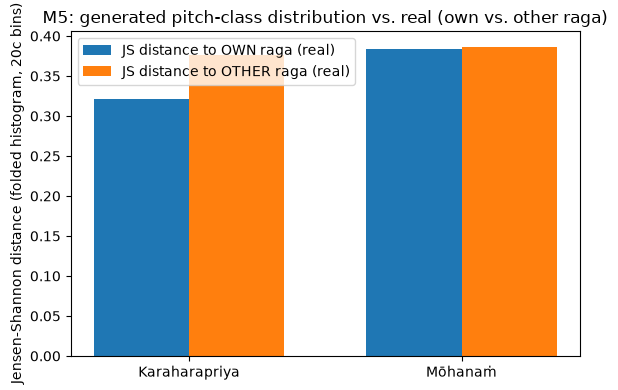

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
bw_plot = 20
sub = HIST[HIST.bin_width == bw_plot]
x = np.arange(len(sub))
width = 0.35
ax.bar(x - width/2, sub.js_to_own_real, width, label="JS distance to OWN raga (real)")
ax.bar(x + width/2, sub.js_to_other_real, width, label="JS distance to OTHER raga (real)")
ax.set_xticks(x); ax.set_xticklabels(sub.raga)
ax.set_ylabel(f"Jensen-Shannon distance (folded histogram, {bw_plot}c bins)")
ax.set_title("M5: generated pitch-class distribution vs. real (own vs. other raga)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "m5_histogram_distance.png"), dpi=150)
plt.show()

## Classifier-called-raga

Judge classifier: same config as M2 (`class_weight="balanced", C=10`), fit fresh
on the real 2.0s windows (this notebook's window length, not M2's 4s), folded
pitch-class-histogram features, swept over the same 4 resolutions. Artist-grouped
CV on real data first as a sanity floor (only 2 artists/raga, so this is close to
a leave-one-artist-out check — the thing M3 could never run, made possible here
because the generator only needs 2 balanced ragas).

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score

CLF_KW = dict(class_weight="balanced", C=10, max_iter=2000)
y_real = WMETA.raga.values
groups_artist = WMETA.artist.values

judge_rows = []
for bw in U.RESOLUTIONS_CENTS:
    X_real = np.stack([U.histogram_feature(U.fold_cents(w), bw) for w in windows])
    splitter, ns = U.make_group_cv(y_real, groups_artist, max_splits=5)
    pred_cv = cross_val_predict(LogisticRegression(**CLF_KW), X_real, y_real, cv=splitter, groups=groups_artist)
    real_sanity_bal_acc = balanced_accuracy_score(y_real, pred_cv)

    judge = LogisticRegression(**CLF_KW).fit(X_real, y_real)
    for raga in RAGAS:
        X_gen = np.stack([U.histogram_feature(U.fold_cents(s), bw) for s in generated[raga]])
        preds = judge.predict(X_gen)
        judge_rows.append(dict(bin_width=bw, raga=raga,
                                judge_call_accuracy=float((preds == raga).mean()),
                                n_generated=len(preds),
                                real_artist_grouped_cv_bal_acc=real_sanity_bal_acc, cv_n_splits=ns))

JUDGE = pd.DataFrame(judge_rows)
print(JUDGE.round(3).to_string(index=False))
print("\nchance level for this 2-class problem = 0.5")

 bin_width          raga  judge_call_accuracy  n_generated  real_artist_grouped_cv_bal_acc  cv_n_splits
        10 Karaharapriya                0.167            6                           0.601            2
        10       Mōhanaṁ                1.000            6                           0.601            2
        20 Karaharapriya                0.833            6                           0.591            2
        20       Mōhanaṁ                0.667            6                           0.591            2
        50 Karaharapriya                0.833            6                           0.578            2
        50       Mōhanaṁ                0.500            6                           0.578            2
       100 Karaharapriya                0.833            6                           0.576            2
       100       Mōhanaṁ                0.500            6                           0.576            2

chance level for this 2-class problem = 0.5


## Memorisation check

Nearest-neighbour RMS distance (cents, computed directly on the 230-frame
unfolded window — same length and rate for generated and real, so no DTW needed)
from each generated sample to the full real-window pool, against a real-to-real
leave-one-out baseline (subsampled to 200 real windows for speed). If generation
were mostly copying, generated-to-real distances would cluster near the low end
of that baseline instead of sitting well above it.

In [14]:
def nn_rms_distance(query, pool):
    d = np.sqrt(((pool - query[None, :]) ** 2).mean(axis=1))
    return d.min(), int(d.argmin())

real_stack = np.stack(windows)  # (934, 230)

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(real_stack), size=min(200, len(real_stack)), replace=False)
real_nn = np.array([nn_rms_distance(real_stack[i], np.delete(real_stack, i, axis=0))[0] for i in sample_idx])

mem_rows = []
for raga in RAGAS:
    for i, s in enumerate(generated[raga]):
        d, j = nn_rms_distance(s, real_stack)
        mem_rows.append(dict(raga=raga, sample=i, nn_dist_rms_cents=d,
                              nn_real_raga=WMETA.raga.iloc[j], nn_real_artist=WMETA.artist.iloc[j]))
MEM = pd.DataFrame(mem_rows).sort_values("nn_dist_rms_cents")
print(f"real-to-real NN baseline (n={len(real_nn)}): median={np.median(real_nn):.1f}c, "
      f"min={real_nn.min():.1f}c, p5={np.percentile(real_nn,5):.1f}c")
print(f"generated-to-real NN (n={len(MEM)}): median={MEM.nn_dist_rms_cents.median():.1f}c, "
      f"min={MEM.nn_dist_rms_cents.min():.1f}c")
print()
print(MEM.round(1).to_string(index=False))

real-to-real NN baseline (n=200): median=161.9c, min=7.1c, p5=11.4c
generated-to-real NN (n=12): median=149.3c, min=13.9c

         raga  sample  nn_dist_rms_cents  nn_real_raga       nn_real_artist
      Mōhanaṁ       0          13.900000 Karaharapriya           KP Nandini
      Mōhanaṁ       2          16.700001 Karaharapriya V. Shankaranarayanan
      Mōhanaṁ       5          50.099998 Karaharapriya           KP Nandini
Karaharapriya       4         109.000000       Mōhanaṁ     Sumithra Vasudev
Karaharapriya       0         126.199997 Karaharapriya V. Shankaranarayanan
      Mōhanaṁ       4         145.100006       Mōhanaṁ     Sumithra Vasudev
Karaharapriya       5         153.500000       Mōhanaṁ    Ashwath Narayanan
Karaharapriya       1         185.699997 Karaharapriya           KP Nandini
      Mōhanaṁ       1         212.699997       Mōhanaṁ    Ashwath Narayanan
      Mōhanaṁ       3         223.199997 Karaharapriya           KP Nandini
Karaharapriya       2         242.100006 

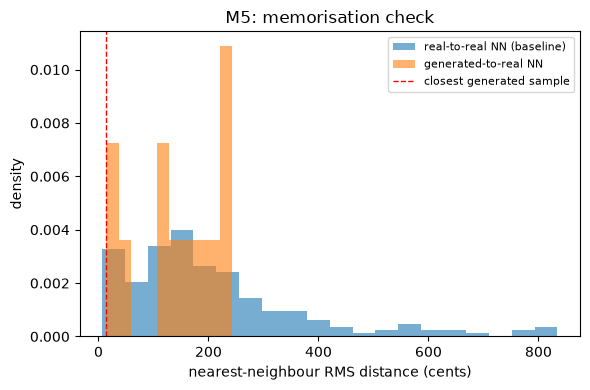

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(real_nn, bins=20, alpha=0.6, label="real-to-real NN (baseline)", density=True)
ax.hist(MEM.nn_dist_rms_cents, bins=10, alpha=0.6, label="generated-to-real NN", density=True)
ax.axvline(MEM.nn_dist_rms_cents.min(), color="red", linestyle="--", linewidth=1,
           label="closest generated sample")
ax.set_xlabel("nearest-neighbour RMS distance (cents)")
ax.set_ylabel("density")
ax.set_title("M5: memorisation check")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "m5_memorisation_check.png"), dpi=150)
plt.show()

## Numbers → `artifacts/numbers.json["m5"]`

In [16]:
NUMBERS["m5"] = {
    "histogram_distance": HIST.to_dict(orient="records"),
    "judge_classifier": {
        "config": "LogisticRegression(class_weight=balanced, C=10), fresh fit (M2's fitted models not persisted)",
        "bin_width_resolutions_cents": U.RESOLUTIONS_CENTS,
        "results": JUDGE.to_dict(orient="records"),
    },
    "memorisation_check": {
        "real_to_real_nn_baseline_median_cents": float(np.median(real_nn)),
        "real_to_real_nn_baseline_min_cents": float(real_nn.min()),
        "generated_to_real_nn_median_cents": float(MEM.nn_dist_rms_cents.median()),
        "generated_to_real_nn_min_cents": float(MEM.nn_dist_rms_cents.min()),
        "n_real_baseline_sampled": int(len(real_nn)),
        "n_generated_checked": int(len(MEM)),
    },
    "framing": "proof-of-concept: 6 generated samples/raga vs. 2 real recordings/raga; "
               "all numbers suggestive, not confident generation-quality claims",
}
with open(os.path.join(ART, "numbers.json"), "w", encoding="utf-8") as f:
    json.dump(NUMBERS, f, indent=2, ensure_ascii=False)
print("wrote numbers.json[m5]")

wrote numbers.json[m5]
